# Route 66
This is a map of the places named in the Nat King Cole and Chuck Berry song Route 66. It can give us a sense of which cities were most culturally significant in this period.

Towns with bigger population sizes have been represented with larger dots. Data was taken from the 1950 US census. However, no data had been collected for Winona - a very small town - meaning this has been estimated by dividing the population of its county (Coconino county) in 1950 by 1000. This was an arbritary choice.

Towns in the song:<br>
Well, if you ever plan to motor west<br>
Jack, take my way, it's the highway that's the best<br>
Get your kicks on Route 66<br>

Well it winds from **Chicago** to **L.A.** <br>
More than two-thousand miles all the way<br>
Get your kicks on Route 66<br>

Well, it goes from **St. Louie**, **Joplin**, Missouri <br>
**Oklahoma City** looks ooh so pretty <br>
You'll see **Amarillo** and **Gallup**, New Mexico <br>
**Flagstaff**, Arizona, don't forget **Winona** <br>
**Kingsman**, **Barstow**, **San Bernardino** <br>

Won't you get hip on that kindly tip <br>
Jack and take that California trip? <br>
Get your kicks on Route 66 <br>

Well, it goes from **St. Louie**, **Joplin**, Missouri <br>
**Oklahoma City** looks, ooh, so pretty <br>
You'll see **Amarillo**, **Gallup**, New Mexico <br>
**Flagstaff**, Arizona, don't forget **Winona** <br>
**Kingsman**, **Barstow**, **San Bernardino** <br>

Won't you get hip on that kindly tip <br>
Jack and take that California trip? <br>
Get your kicks on Route 66 <br>

Get your kicks on Route 66 <br>
Get your kicks on Route 66 <br> 
Get your kicks on Route 66

Let's manually create a dataset containing the cities listed in the song, their latitudes and their longitudes.

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import pandas as pd

# dataset of cities and population sizes
data = {"city":["Chicago","L.A.","St. Louie","Joplin", "Oklahoma City", "Amarillo", "Gallup", "Flagstaff", "Winona", "Kingsman", "Barstow", "San Bernardino"],
       "latitude":[41.864951371481055, 34.0962670530509, 38.655179367913625, 37.07898540235688, 35.49240953364765, 35.19886030208132, 35.521631100151815, 35.20132528620923, 35.20437302414543, 35.211891029663576, 34.8751862535193, 34.124263927874594],
       "longitude":[-87.61933052491747, -118.28408561602494, -90.22646601365103, -94.50177137421815, -97.54518121343506, -101.83061605275282, -108.73931417041793, -111.63638374575793, -111.40511972258619, -113.99956698056121, -117.07946180592441, -117.29518288210404],
       "population":[3620962,4046000,1407000,38515,278000,73935,9143,6733,23755*0.001,3314,6130,62798]} # in 1950, no data for Winona

df = pd.DataFrame(data)
df

,city,latitude,longitude,population
0,Chicago,41.864951,-87.619331,3620962.000
1,L.A.,34.096267,-118.284086,4046000.000
2,St. Louie,38.655179,-90.226466,1407000.000
3,Joplin,37.078985,-94.501771,38515.000
4,Oklahoma City,35.492410,-97.545181,278000.000
5,Amarillo,35.198860,-101.830616,73935.000
6,Gallup,35.521631,-108.739314,9143.000
7,Flagstaff,35.201325,-111.636384,6733.000
8,Winona,35.204373,-111.405120,23.755
9,Kingsman,35.211891,-113.999567,3314.000


Now let's plot this data against a map of the US. The Mercator projection has been used to make the map more visually appealing.

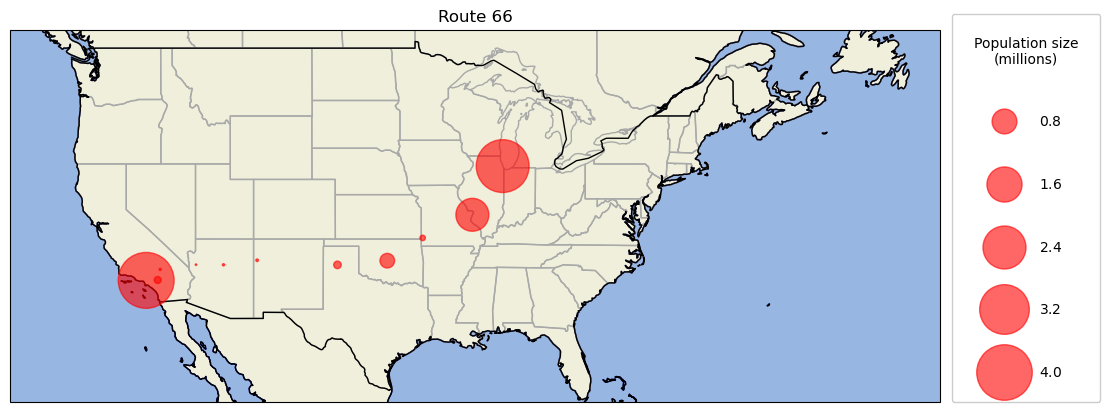

In [77]:
# plot map of US
mapProjection = ccrs.Mercator(min_latitude=20, max_latitude=55)
dataTransform = ccrs.PlateCarree()

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=mapProjection)
ax.set_extent([-130, -50, 25, 50], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, edgecolor="white")
ax.add_feature(cfeature.OCEAN, edgecolor="navy")
ax.add_feature(cfeature.STATES, edgecolor="darkgrey")
ax.add_feature(cfeature.BORDERS, edgecolor="black")
ax.add_feature(cfeature.COASTLINE, edgecolor="black")

# plot cities
m = ax.scatter(x=df.longitude, y=df.latitude, color="red", s=df.population/2500, alpha=0.6, zorder=3, transform=dataTransform)

# add label to graph
l1 = ax.legend(*m.legend_elements(prop="sizes", num=6, func=lambda x: x*2500, color="red"),
               title="Population size\n(millions)", framealpha=1, loc="lower right",
               bbox_to_anchor=(1.18, -0.02), labelspacing=3.5, handletextpad=1.5, borderpad=1.6)
l1.get_title().set_ha("center")

ax.set_title("Route 66")
plt.show()

## Sources
- https://physics.bu.edu/~redner/projects/population/cities/chicago.html
- https://www2.census.gov/library/publications/decennial/1950/pc-02/pc-2-44.pdf p4
- https://www2.census.gov/library/publications/decennial/1950/pc-03/pc-3-09.pdf
- https://www2.census.gov/library/publications/decennial/1950/pc-02/pc-2-45.pdf
- https://www2.census.gov/library/publications/decennial/1950/pc-02/pc-2-16.pdf
- https://www2.census.gov/library/publications/decennial/1950/pc-03/pc-3-08.pdf